# 数値微分: 中央差分 と Savitzky-Golay

ノイズを含むデータに対する微分の比較。

| セクション | 手法 |
|-----------|------|
| 1 | 前進差分・後退差分・中央差分 |
| 2 | Savitzky-Golay微分（ノイズに強い） |

※ Kalman微分は別ファイル `kalman_differentiation.ipynb` を参照

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

from scipy.signal import savgol_filter

# --- 共通設定 ---
np.random.seed(42)

x  = np.linspace(0, 2 * np.pi, 200)
dx = x[1] - x[0]

# ノイズなし真値
y_true  = np.sin(x)
dy_true = np.cos(x)    # 解析的な1次微分

# ノイズあり観測値
noise_level = 0.05
y_noisy     = y_true + np.random.normal(0, noise_level, len(x))

# 誤差(RMSE)関数
rmse = lambda a, b: np.sqrt(np.mean((a - b) ** 2))

print(f"データ点数 : {len(x)}")
print(f"dx         : {dx:.4f}")
print(f"ノイズ標準偏差: {noise_level}")

データ点数 : 200
dx         : 0.0316
ノイズ標準偏差: 0.05


---
## 1. 前進差分 / 後退差分 / 中央差分

$$
\text{前進差分:} \quad f'(x_i) \approx \frac{f(x_{i+1}) - f(x_i)}{\Delta x}
$$
$$
\text{後退差分:} \quad f'(x_i) \approx \frac{f(x_i) - f(x_{i-1})}{\Delta x}
$$
$$
\text{中央差分:} \quad f'(x_i) \approx \frac{f(x_{i+1}) - f(x_{i-1})}{2\Delta x}
$$

中央差分は **2次精度**。前進・後退は1次精度。

In [5]:
def forward_diff(y, dx):
    """前進差分: 末端は後退差分で補完"""
    dy = np.empty_like(y)
    dy[:-1] = (y[1:] - y[:-1]) / dx
    dy[-1]  = (y[-1] - y[-2]) / dx
    return dy

def backward_diff(y, dx):
    """後退差分: 先端は前進差分で補完"""
    dy = np.empty_like(y)
    dy[1:]  = (y[1:] - y[:-1]) / dx
    dy[0]   = (y[1] - y[0]) / dx
    return dy

def central_diff(y, dx):
    """中央差分: 両端は前進/後退差分で補完"""
    dy = np.empty_like(y)
    dy[1:-1] = (y[2:] - y[:-2]) / (2 * dx)
    dy[0]    = (y[1]  - y[0])   / dx
    dy[-1]   = (y[-1] - y[-2])  / dx
    return dy

# ---- 計算 ----
dy_fwd = forward_diff (y_noisy, dx)
dy_bwd = backward_diff(y_noisy, dx)
dy_cen = central_diff (y_noisy, dx)

print(f"前進差分 RMSE: {rmse(dy_fwd, dy_true):.4f}")
print(f"後退差分 RMSE: {rmse(dy_bwd, dy_true):.4f}")
print(f"中央差分 RMSE: {rmse(dy_cen, dy_true):.4f}")

前進差分 RMSE: 2.1326
後退差分 RMSE: 2.1295
中央差分 RMSE: 1.0685


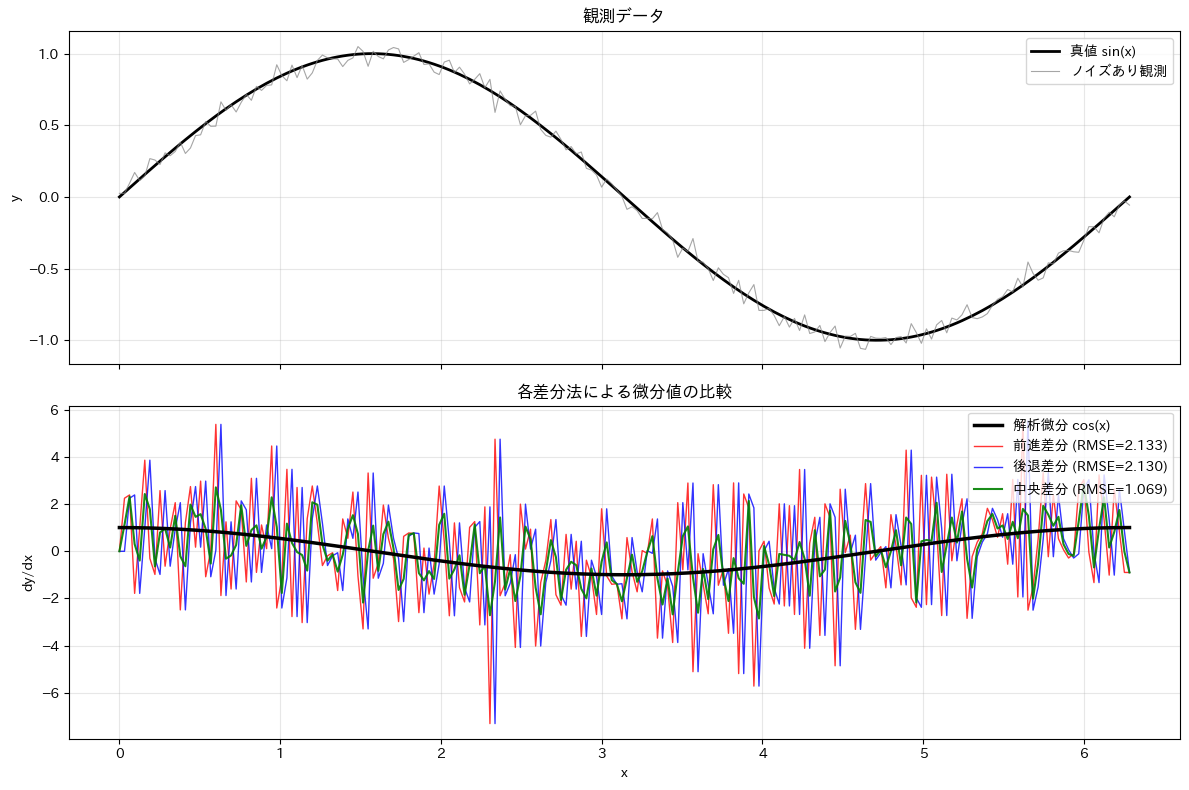


【ポイント】
・中央差分は前進/後退より精度が高い（2次精度）
・ただしノイズには3手法とも弱い → SGフィルタへ


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 上段: 観測データ
ax = axes[0]
ax.plot(x, y_true,  'k-',   lw=2,   label='真値 sin(x)')
ax.plot(x, y_noisy, 'gray', lw=0.8, alpha=0.7, label='ノイズあり観測')
ax.set_ylabel('y')
ax.legend(loc='upper right')
ax.set_title('観測データ')
ax.grid(True, alpha=0.3)

# 下段: 各差分の微分値
ax = axes[1]
ax.plot(x, dy_true, 'k-', lw=2.5, label='解析微分 cos(x)', zorder=5)
ax.plot(x, dy_fwd,  'r-', lw=1,   alpha=0.8, label=f'前進差分 (RMSE={rmse(dy_fwd, dy_true):.3f})')
ax.plot(x, dy_bwd,  'b-', lw=1,   alpha=0.8, label=f'後退差分 (RMSE={rmse(dy_bwd, dy_true):.3f})')
ax.plot(x, dy_cen,  'g-', lw=1.5, alpha=0.9, label=f'中央差分 (RMSE={rmse(dy_cen, dy_true):.3f})')
ax.set_xlabel('x')
ax.set_ylabel('dy/dx')
ax.legend(loc='upper right')
ax.set_title('各差分法による微分値の比較')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n【ポイント】")
print("・中央差分は前進/後退より精度が高い（2次精度）")
print("・ただしノイズには3手法とも弱い → SGフィルタへ")

---
## 2. Savitzky-Golay 微分

局所的な窓内のデータを **多項式でフィッティング** し、その多項式の解析微分を使う。

- `window_length` : 窓幅（奇数）。大きいほど滑らか・高ノイズ耐性。鋭いピークは潰しやすい
- `polyorder`     : 多項式次数。大きいほど細かい変化を追従
- `deriv`         : 微分階数（1=1次, 2=2次）
- `delta`         : データ間隔 dx

> `scipy.signal.savgol_filter(y, window_length, polyorder, deriv=1, delta=dx)`

In [7]:
# ---- 窓幅・次数の組み合わせを比較 ----
sg_params = [
    {'window_length':  9, 'polyorder': 2, 'label': 'window=9,  poly=2'},
    {'window_length': 21, 'polyorder': 3, 'label': 'window=21, poly=3'},
    {'window_length': 51, 'polyorder': 4, 'label': 'window=51, poly=4'},
    {'window_length': 11, 'polyorder': 5, 'label': 'window=11, poly=5'},
]

sg_results = []
for p in sg_params:
    dy_sg = savgol_filter(
        y_noisy,
        window_length = p['window_length'],
        polyorder     = p['polyorder'],
        deriv         = 1,
        delta         = dx
    )
    err = rmse(dy_sg, dy_true)
    sg_results.append({'dy': dy_sg, 'rmse': err, **p})
    print(f"{p['label']:30s}  RMSE={err:.4f}")

window=9,  poly=2               RMSE=0.1750
window=21, poly=3               RMSE=0.1490
window=51, poly=4               RMSE=0.0547
window=11, poly=5               RMSE=0.7153


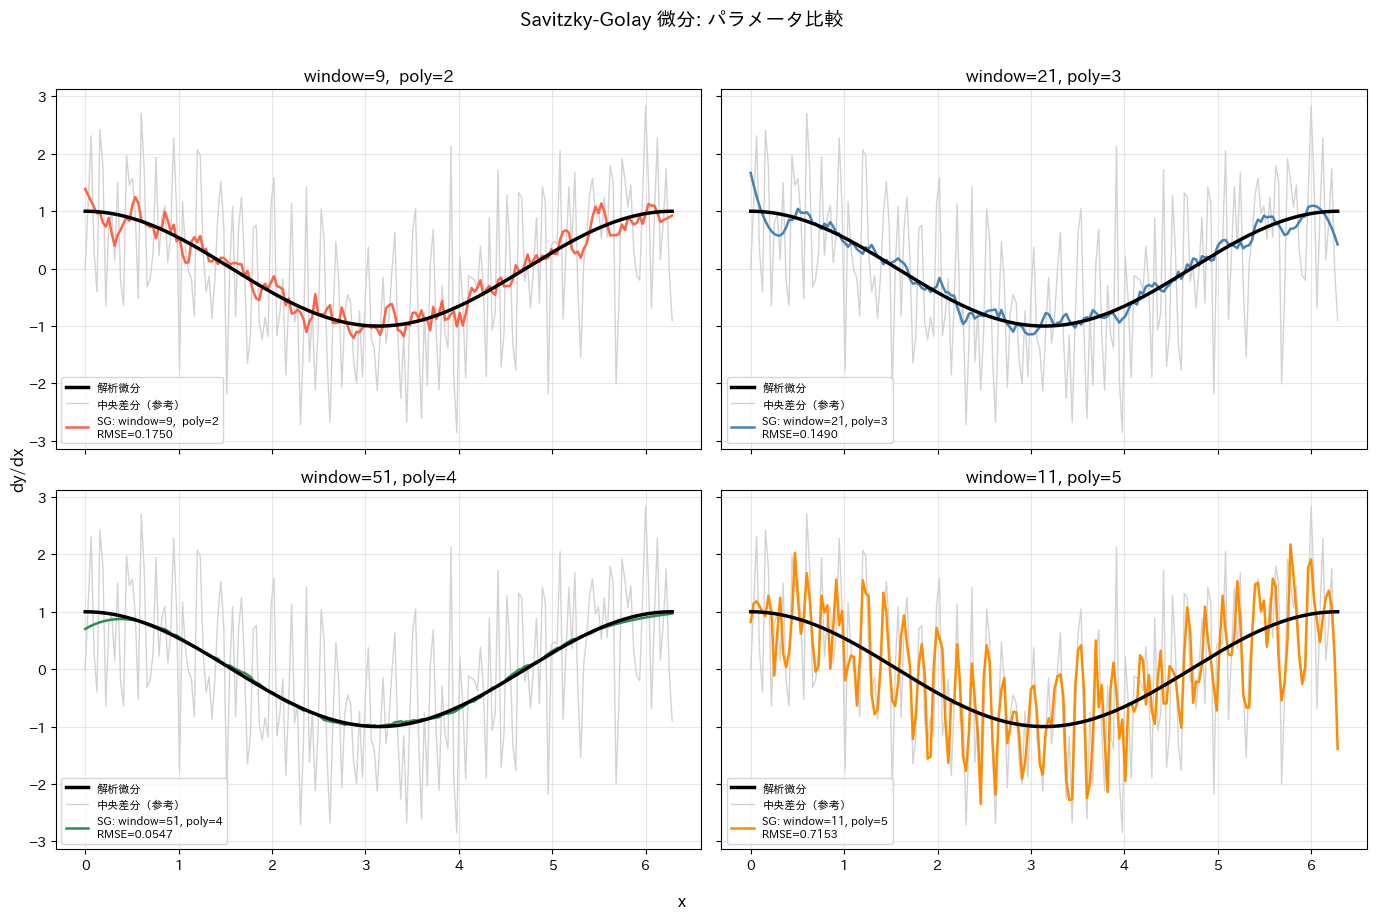


【ポイント】
・window が大きい → 滑らか、ノイズに強い、ただし鋭い変化を見逃しやすい
・polyorder が大きい → 複雑な形状を追従できるが、過フィットに注意
・スペクトル2次微分には window=11～21, polyorder=3～5 あたりが定番


In [8]:
colors = ['tomato', 'steelblue', 'seagreen', 'darkorange']

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)

for ax, res, color in zip(axes.flat, sg_results, colors):
    ax.plot(x, dy_true, 'k-', lw=2.5, label='解析微分', zorder=5)
    ax.plot(x, dy_cen,  'lightgray', lw=1, label='中央差分（参考）')
    ax.plot(x, res['dy'], color=color, lw=1.8,
            label=f"SG: {res['label']}\nRMSE={res['rmse']:.4f}")
    ax.set_title(res['label'])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.supxlabel('x', fontsize=12)
fig.supylabel('dy/dx', fontsize=12)
fig.suptitle('Savitzky-Golay 微分: パラメータ比較', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\n【ポイント】")
print("・window が大きい → 滑らか、ノイズに強い、ただし鋭い変化を見逃しやすい")
print("・polyorder が大きい → 複雑な形状を追従できるが、過フィットに注意")
print("・スペクトル2次微分には window=11～21, polyorder=3～5 あたりが定番")

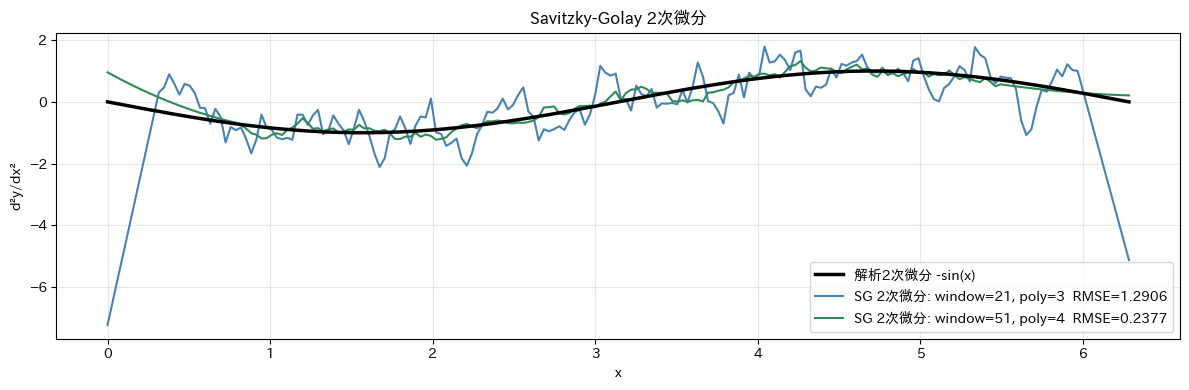

In [9]:
# ---- 2次微分（スペクトルのピーク検出に有用）----
dy2_true = -np.sin(x)   # sin の解析2次微分

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x, dy2_true, 'k-', lw=2.5, label='解析2次微分 -sin(x)', zorder=5)

for p, color in zip(sg_params[1:3], ['steelblue', 'seagreen']):
    dy2_sg = savgol_filter(
        y_noisy,
        window_length = p['window_length'],
        polyorder     = p['polyorder'],
        deriv         = 2,
        delta         = dx
    )
    err2 = rmse(dy2_sg, dy2_true)
    ax.plot(x, dy2_sg, color=color, lw=1.5,
            label=f"SG 2次微分: {p['label']}  RMSE={err2:.4f}")

ax.set_xlabel('x')
ax.set_ylabel('d²y/dx²')
ax.set_title('Savitzky-Golay 2次微分')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## まとめ

| 手法 | ノイズ耐性 | 計算コスト | 向いているケース |
|------|:---------:|:---------:|------------------|
| 前進/後退差分 | 低 | 最小 | ノイズがほぼない、端点処理 |
| 中央差分 | 低 | 最小 | ノイズが少ない、精度優先の内点 |
| **Savitzky-Golay** | 高 | 小 | スペクトル、生体信号（推奨） |